In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Notebook çalışıyor!")

Notebook çalışıyor!


# 1. Data Loading

In [2]:
df = pd.read_csv("trainDataSet.csv", sep=';')  # Noktalı virgül ile ayrılmış CSV

# 2. Data Exploration

In [3]:
# Kolon isimlerini kontrol et
print("Kolonlar:", df.columns)

# DepDelayMinutes kolonunun tipini kontrol et ve sayısal yap
print("ArrDelayMinutes dtype:", df['ArrDelayMinutes'].dtype)
df['ArrDelayMinutes'] = pd.to_numeric(df['ArrDelayMinutes'], errors='coerce')

# NaN varsa temizle
df = df.dropna(subset=['ArrDelayMinutes'])

# Korelasyonları hesapla
print("ArrDelayMinutes korelasyonları:\n", df.corr(numeric_only=True)['ArrDelayMinutes'].sort_values(ascending=False))

Kolonlar: Index(['Month', 'DayOfWeek', 'FlightDate', 'Operating_Airline',
       'Flight_Number_Operating_Airline', 'OriginAirportID', 'Origin',
       'OriginCityName', 'DestAirportID', 'Dest', 'DestCityName', 'CRSDepTime',
       'DepTime', 'DepDelayMinutes', 'DepDel15', 'CRSArrTime', 'ArrTime',
       'ArrDelayMinutes', 'ArrDel15', 'Cancelled', 'CancellationCode',
       'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay'],
      dtype='str')
ArrDelayMinutes dtype: int64
ArrDelayMinutes korelasyonları:
 ArrDelayMinutes                    1.000000
DepDelayMinutes                    0.682131
LateAircraftDelay                  0.493378
DepDel15                           0.383954
NASDelay                           0.379584
CarrierDelay                       0.360913
WeatherDelay                       0.197694
DepTime                            0.131981
CRSDepTime         

# 3. Feature Selection

In [4]:
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

# Feature ve target
X_train = df_train[['LateAircraftDelay']]         # Feature
y_train = df_train['ArrDelayMinutes']    # Target

X_test = df_test[['LateAircraftDelay']]
y_test = df_test['ArrDelayMinutes']

# 4. Model Training

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 5. Prediction & Visualization

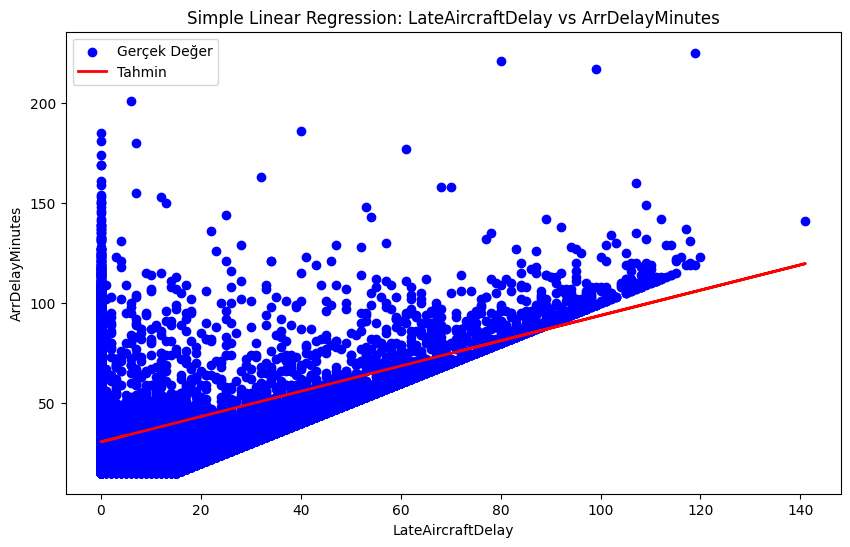

In [6]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', label='Gerçek Değer')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Tahmin')
plt.xlabel('LateAircraftDelay')
plt.ylabel('ArrDelayMinutes')
plt.title('Simple Linear Regression: LateAircraftDelay vs ArrDelayMinutes')
plt.legend()
plt.show()